In [11]:
import torch
import torch.nn as nn
import math
x = torch.randn(1,196,768)
print(x.shape)
x = x.reshape(1,14,14,768).permute(0,3,1,2)
print(x.shape)
x = nn.functional.interpolate( 
            
            #w,h가 다르니까 interpolate함수로 img_size // patch_size 로 크기를 맞춰주기
            #B,patch_size,patch_size,E -> #B,E,p,p -> B,p,p,E
            input = x.reshape(1,14,14,768).permute(0,3,1,2),
            scale_factor = (14.1 / 14, 15.2 / 14),
            mode = "bicubic"
        )
print(x.shape)
x = x.permute(0,2,3,1)     
print(x.shape)
x = x.view(1,-1,768)
print(x.shape)
math.sqrt(14)   

torch.Size([1, 196, 768])
torch.Size([1, 768, 14, 14])
torch.Size([1, 768, 14, 15])
torch.Size([1, 14, 15, 768])
torch.Size([1, 210, 768])


3.7416573867739413

In [2]:
import argparse
import os
import torch
import torch.nn as nn
from pathlib import Path
import numpy as np

class DINOLoss(nn.Module):
    def __init__(self, out_dim, ncrops, warmup_teacher_temp, teacher_temp, warmup_teacher_temp_epochs, nepochs, student_temp = 0.1, center_momentum = 0.9):
        super().__init__()
        self.student_temp = student_temp
        self.center_momentum = center_momentum
        self.ncrops = ncrops
        self.register_buffer("center", torch.zeros(1, out_dim))
        self.teacher_temp_schedule = np.concatenate((
            np.linspace(warmup_teacher_temp,
                        teacher_temp, warmup_teacher_temp_epochs),
            np.ones(nepochs - warmup_teacher_temp_epochs) * teacher_temp
        ))
        print(self.teacher_temp_schedule)
    def forward(self,x):
        student_out = student_output / self.student_temp
        student_out = student_out.chunk(self.ncrops) # chunk : ncrops개로 리스트를 분할

dino_loss = DINOLoss(
        65536,
        8 + 2,  # total number of crops = 2 global crops + local_crops_number
        0.04,
        0.04,
        0,
        100,
    )



[0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04
 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04
 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04
 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04
 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04
 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04
 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04
 0.04 0.04]


In [12]:
print(np.linspace(0.04, 3, 20))
print(np.ones(100 - 20)*0.04)
np.concatenate((np.linspace(0.04, 3, 20), np.ones(100 - 0)*0.04))

[0.04       0.19578947 0.35157895 0.50736842 0.66315789 0.81894737
 0.97473684 1.13052632 1.28631579 1.44210526 1.59789474 1.75368421
 1.90947368 2.06526316 2.22105263 2.37684211 2.53263158 2.68842105
 2.84421053 3.        ]
[0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04
 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04
 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04
 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04
 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04
 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04]


array([0.04      , 0.19578947, 0.35157895, 0.50736842, 0.66315789,
       0.81894737, 0.97473684, 1.13052632, 1.28631579, 1.44210526,
       1.59789474, 1.75368421, 1.90947368, 2.06526316, 2.22105263,
       2.37684211, 2.53263158, 2.68842105, 2.84421053, 3.        ,
       0.04      , 0.04      , 0.04      , 0.04      , 0.04      ,
       0.04      , 0.04      , 0.04      , 0.04      , 0.04      ,
       0.04      , 0.04      , 0.04      , 0.04      , 0.04      ,
       0.04      , 0.04      , 0.04      , 0.04      , 0.04      ,
       0.04      , 0.04      , 0.04      , 0.04      , 0.04      ,
       0.04      , 0.04      , 0.04      , 0.04      , 0.04      ,
       0.04      , 0.04      , 0.04      , 0.04      , 0.04      ,
       0.04      , 0.04      , 0.04      , 0.04      , 0.04      ,
       0.04      , 0.04      , 0.04      , 0.04      , 0.04      ,
       0.04      , 0.04      , 0.04      , 0.04      , 0.04      ,
       0.04      , 0.04      , 0.04      , 0.04      , 0.04   

In [32]:
from torch.nn import functional as F
import torch
out_dim = 65536
center = torch.zeros(1, out_dim)
# print(center)

teacher_output = torch.randn(65536)
# print(teacher_output)


# print(F.softmax((teacher_output - center) / 1, dim = -1))
teacher_out = F.softmax((teacher_output - center) / 0.5, dim = -1)
# print(teacher_out)
teacher_out = teacher_out.detach().chunk(16)
print(teacher_out[0].shape)




torch.Size([1, 65536])


# loss계산 좀 보자
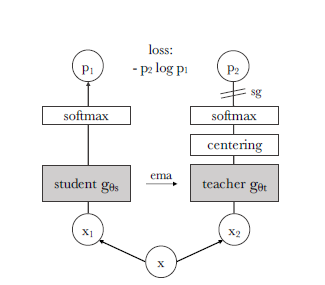

In [ ]:
class DINOLoss(nn.Module):
    def __init__(self, out_dim, ncrops, warmup_teacher_temp, teacher_temp, warmup_teacher_temp_epochs, nepochs, student_temp = 0.1, center_momentum = 0.9):
        super().__init__()
        self.student_temp = student_temp
        self.center_momentum = center_momentum
        self.ncrops = ncrops
        self.register_buffer("center", torch.zeros(1, out_dim))
        self.teacher_temp_schedule = np.concatenate((
            # num만큼 초반 스케쥴러를 도입하는 방식
            np.linspace(start = warmup_teacher_temp,
                        stop = teacher_temp, 
                        num = warmup_teacher_temp_epochs),
            np.ones(nepochs - warmup_teacher_temp_epochs) * teacher_temp
        ))
    def forward(self,student_output, teacher_output, epoch):
        student_out = student_output / self.student_temp
        student_out = student_out.chunk(self.ncrops) # chunk : ncrops개로 리스트를 분할

        temp = self.teacher_temp_schedule[epoch]
        teacher_out = F.softmax((teacher_output - self.center) / temp, dim = -1)
        teacher_out = teacher_out.detach().chunk(2) #이거 왜 2지?

        total_loss = 0
        n_loss_terms = 0
        for iq,q in enumerate(teacher_out):
            for v in range(len(student_out)):
                if v ==iq :
                    continue
                loss = torch.sum(-q * F.log_softmax(student_out[v], dim= -1), dim=-1)

dino_loss = DINOLoss(
        65536,
        8 + 2,  # total number of crops = 2 global crops + local_crops_number
        0.04,
        0.04,
        0,
        100,
    )         
student_out = torch.randn(16,20,)
teacher_out = 
epoch = 3           
dino_loss()    

In [ ]:
import matplotlib.pyplot as pyplot
import torchvision.transforms as transforms

plt.figure(figsize = (8,8))
for i in range(9):
    pil_image = PIL.Image.open()

In [4]:
from PIL import Image, ImageFilter 

# creating a image object 
im1 = Image.open("/mnt/hdd_6tb/bill0914/dino_from scratch/서명.png") 

# applying the Gaussian Blur filter 
im2 = im1.filter(ImageFilter.GaussianBlur(radius = 5))

im2.save("2.png") 

# apply함수와 init_weight에 대한 실험

In [17]:

import torch
import torch.nn as nn
@torch.no_grad()
def __init__weights(m):
    if isinstance(m,nn.Linear):
        m.weight.fill_(1.0)
        
        if isinstance(m,nn.Linear) and m.bias is not None:
            nn.init.constant_(m.bias, 0)


n = nn.Sequential(nn.Linear(2,2),nn.Linear(2,2))
print(n)            
print(nn.Linear(2,2).weight)
n.apply(__init__weights)

Sequential(
  (0): Linear(in_features=2, out_features=2, bias=True)
  (1): Linear(in_features=2, out_features=2, bias=True)
)
Parameter containing:
tensor([[0.3220, 0.3518],
        [0.1294, 0.6428]], requires_grad=True)


Sequential(
  (0): Linear(in_features=2, out_features=2, bias=True)
  (1): Linear(in_features=2, out_features=2, bias=True)
)

In [19]:
layers = [nn.Linear(256, 768)]
layers.append(nn.BatchNorm1d(768))
layers.append(nn.GELU())
layers.append(nn.Linear(768,768))
layers.append(nn.Linear(768,768))
layers.append(nn.BatchNorm1d(768))
layers.append(nn.GELU())
layers.append(nn.Linear(768, 384))
mlp = nn.Sequential(*layers)
mlp.apply(__init__weights)

x = torch.randn(16,256)
x = mlp(x)
print(x[0])
nn.functional.normalize(x, dim=-1, p = 2)
print(x[0])
last_layer = nn.utils.weight_norm(nn.Linear(384, 128, bias = False)) 
last_layer.weight_g.data.fill_(1)
last_layer.weight_g.requires_grad = False
out = last_layer(x)
out[0]

tensor([-116.9286, -116.9286, -116.9286, -116.9286, -116.9286, -116.9286,
        -116.9286, -116.9286, -116.9286, -116.9286, -116.9286, -116.9286,
        -116.9286, -116.9286, -116.9286, -116.9286, -116.9286, -116.9286,
        -116.9286, -116.9286, -116.9286, -116.9286, -116.9286, -116.9286,
        -116.9286, -116.9286, -116.9286, -116.9286, -116.9286, -116.9286,
        -116.9286, -116.9286, -116.9286, -116.9286, -116.9286, -116.9286,
        -116.9286, -116.9286, -116.9286, -116.9286, -116.9286, -116.9286,
        -116.9286, -116.9286, -116.9286, -116.9286, -116.9286, -116.9286,
        -116.9286, -116.9286, -116.9286, -116.9286, -116.9286, -116.9286,
        -116.9286, -116.9286, -116.9286, -116.9286, -116.9286, -116.9286,
        -116.9286, -116.9286, -116.9286, -116.9286, -116.9286, -116.9286,
        -116.9286, -116.9286, -116.9286, -116.9286, -116.9286, -116.9286,
        -116.9286, -116.9286, -116.9286, -116.9286, -116.9286, -116.9286,
        -116.9286, -116.9286, -116.928

/home/bill0914/anaconda3/envs/FastViT/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


tensor([ -53.3416, -241.0209,   69.1522,  -50.8007,  -49.0812,   21.8180,
         117.8524,  -43.1220,  -68.2206,  -81.2666, -206.4964, -329.2356,
         -12.7297,   66.6459,  -53.0480,   65.9158,  -64.8762,  169.6602,
        -150.8579,  -10.4059,  -21.7214,    7.4421,  171.1605,   25.5329,
        -177.6535,   39.7165, -273.6837,   86.9427, -224.5208, -128.8886,
          -6.0242,  -12.5905,  -83.5243,  -42.8328,  -69.0572,   18.8338,
          -5.8647,  -11.7864,   96.8807,  203.6262,  -13.9099,  130.0892,
          23.8490,   32.5057,   54.0832,   15.4192,  -20.1681,  -14.6741,
          24.3000,   93.8710,  -21.8822,  -82.9554,  -73.9382,  108.8732,
         -76.7669,   23.8386,  157.8076,  163.8218,  118.5753,   81.3511,
         141.4657, -112.6768,  -37.6485,   -4.2674,   73.9784,    5.7356,
          90.5631,   73.9832, -210.6846,   25.3921,  108.1430, -170.5741,
        -230.2191,  151.9036,   50.6507,  180.5115,   96.0272,  108.4561,
         171.6374,  -41.2912, -135.532